# 観測カテゴリMNARモデル n=1,000
## 結論
MCAR/MAR/MNAR各100反復。MNARのoutcome平均biasは候補法で小さい一方、境界解19/100で通常のWald推論は未解決。
保存済みMonte Carlo結果を検証・再集計する実行済みnotebook。新スライドと本文図表は同じCSVから生成する。
## 方法
V=(W,Z) -> F -> Yj、(Y1,Yj) -> Dj。X固定、Y1常時観測、2クラス、条件付き独立な応答。
piは各Y1,Yjセルで自由。旧block bridgeではなく共通測定核を課した観測尤度を用いる。
飽和selectionと正指定の全交互作用logisticは同じモデルなので4手法を比較する。
母集団の三方向rankは2+2+2。旧4セルblock completenessは不成立。
## 再実行
リポジトリ直下から `simulation/.venv/bin/python simulation/observed_category/experiment.py --sample-size 1000 --output results_n1000`。
生成・推定のコードと設定は同ディレクトリに保存されている。

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image
root=Path.cwd()
if not (root/'experiment.py').exists(): root=root/'simulation'/'observed_category'
sys.path.insert(0,str(root))
import build_n1000_report as report
import experiment as e
import pandas as pd
summary, diagnostics, raw=report.load()
checks=pd.DataFrame([r for m in e.config()['mechanisms'] for r in e.population_checks(e.config(),m)])
display(checks)
display(report.make_report().round(4))

,mechanism,stratum,matrix,rank,sigma_min,inverse_determinant
0,MCAR,0,K2,2,3.500000e-01,0.245000
1,MCAR,0,K3,2,4.543999e-01,0.318500
2,MCAR,1,K2,2,3.500000e-01,0.245000
3,MCAR,1,K3,2,4.543999e-01,0.318500
4,MCAR,both,G,2,3.838308e-01,NaN
5,MCAR,fixed X,old_pair_12,2,2.269709e-18,NaN
6,MCAR,fixed X,old_pair_13,2,5.463924e-18,NaN
7,MAR,0,K2,2,3.733188e-01,0.278734
8,MAR,0,K3,2,4.845664e-01,0.362354
9,MAR,1,K2,2,3.206210e-01,0.205596


,mechanism,method,M_abs_bias,M_RMSE,p_bias,p_RMSE,valid_CI
0,MAR,MAR_ignorability,0.0028,0.0302,0.0092,0.0331,100
1,MAR,candidate_saturated,0.0040,0.0444,0.0103,0.0346,94
2,MAR,oracle,0.0023,0.0247,0.0052,0.0256,100
3,MAR,selection_misspecified,0.0364,0.0511,0.0253,0.0410,100
4,MCAR,MAR_ignorability,0.0030,0.0303,0.0078,0.0328,100
5,MCAR,candidate_saturated,0.0035,0.0429,0.0090,0.0345,94
6,MCAR,oracle,0.0023,0.0247,0.0052,0.0256,100
7,MCAR,selection_misspecified,0.0026,0.0328,0.0085,0.0332,100
8,MNAR,MAR_ignorability,0.0718,0.0816,-0.0097,0.0397,91
9,MNAR,candidate_saturated,0.0042,0.0387,0.0072,0.0295,81


## 推論と診断
bias・SD・RMSEは全100反復。SEとcoverage_validはCIが有効な反復のみ。
境界解・非収束・非正定値HessianにWald CIを付与しない。CI成功率も必ず併記する。
制約されたselection (Yjのみ) はMCARで正指定、今回のMAR/MNARで誤指定。

boundary  valid_se  stationary  item_rate  \
mechanism method                                                              
MAR       MAR_ignorability            0.00      1.00         1.0   0.799750   
          candidate_saturated         0.06      0.94         1.0   0.799750   
          oracle                      0.00      1.00         1.0   0.799750   
          selection_misspecified      0.00      1.00         1.0   0.799750   
MCAR      MAR_ignorability            0.00      1.00         1.0   0.800330   
          candidate_saturated         0.06      0.94         1.0   0.800330   
          oracle                      0.00      1.00         1.0   0.800330   
          selection_misspecified      0.00      1.00         1.0   0.800330   
MNAR      MAR_ignorability            0.09      0.91         1.0   0.799357   
          candidate_saturated         0.19      0.81         1.0   0.799357   
          oracle                      0.00      1.00         1.0   0.799357   
          selection_misspecified      1.00      0.00         1.0   0.799357   

                                  complete_rate  
mechanism method                                 
MAR       MAR_ignorability              0.49264  
          candidate_saturated           0.49264  
          oracle                        0.49264  
          selection_misspecified        0.49264  
MCAR      MAR_ignorability              0.49072  
          candidate_saturated           0.49072  
          oracle                        0.49072  
          selection_misspecified        0.49072  
MNAR      MAR_ignorability              0.52018  
          candidate_saturated           0.52018  
          oracle                        0.52018  
          selection_misspecified        0.52018

,mechanism,method,parameter,bias,RMSE,SD,estimated_SE,coverage_valid,valid_CI,SD_valid,CI_failure_rate,covered_and_available,bias_MCSE,replications
147,MNAR,MAR_ignorability,M2_class2,-0.1635,0.1677,0.0372,0.0418,0.0220,91,0.0371,0.09,0.02,0.0037,100
149,MNAR,MAR_ignorability,M3_class2,-0.1373,0.1465,0.0515,0.0464,0.2088,91,0.0532,0.09,0.19,0.0052,100
159,MNAR,MAR_ignorability,mean_Y2,-0.0914,0.0930,0.0174,0.0187,0.0000,91,0.0169,0.09,0.00,0.0017,100
160,MNAR,MAR_ignorability,mean_Y3,-0.0801,0.0822,0.0184,0.0189,0.0110,91,0.0187,0.09,0.01,0.0018,100
161,MNAR,MAR_ignorability,p_class2,-0.0097,0.0397,0.0387,0.0384,0.9011,91,0.0390,0.09,0.82,0.0039,100
165,MNAR,candidate_saturated,M2_class2,-0.0117,0.0490,0.0478,0.0525,1.0000,81,0.0497,0.19,0.81,0.0048,100
167,MNAR,candidate_saturated,M3_class2,-0.0052,0.0413,0.0411,0.0428,0.9753,81,0.0411,0.19,0.79,0.0041,100
177,MNAR,candidate_saturated,mean_Y2,-0.0009,0.0351,0.0352,0.0400,0.9753,81,0.0347,0.19,0.79,0.0035,100
178,MNAR,candidate_saturated,mean_Y3,0.0029,0.0288,0.0288,0.0329,0.9630,81,0.0272,0.19,0.78,0.0029,100
179,MNAR,candidate_saturated,p_class2,0.0072,0.0295,0.0288,0.0331,0.9506,81,0.0283,0.19,0.77,0.0029,100


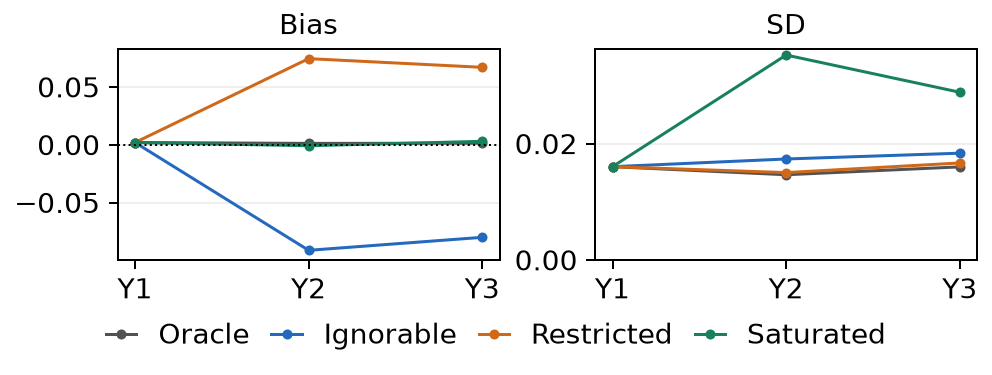

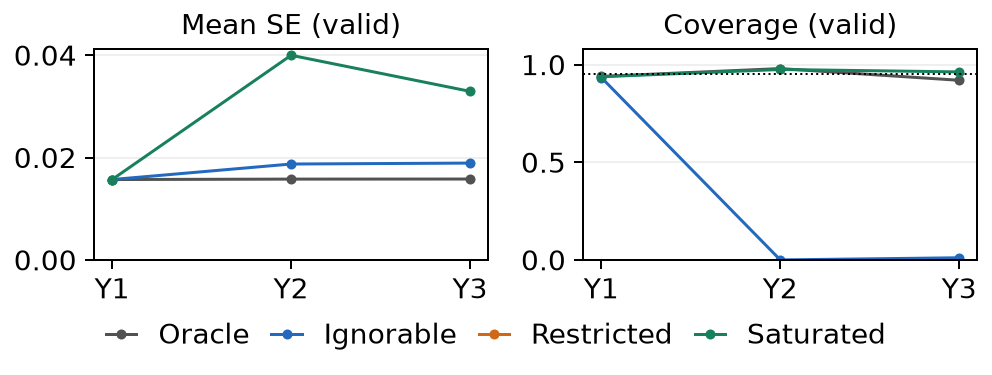

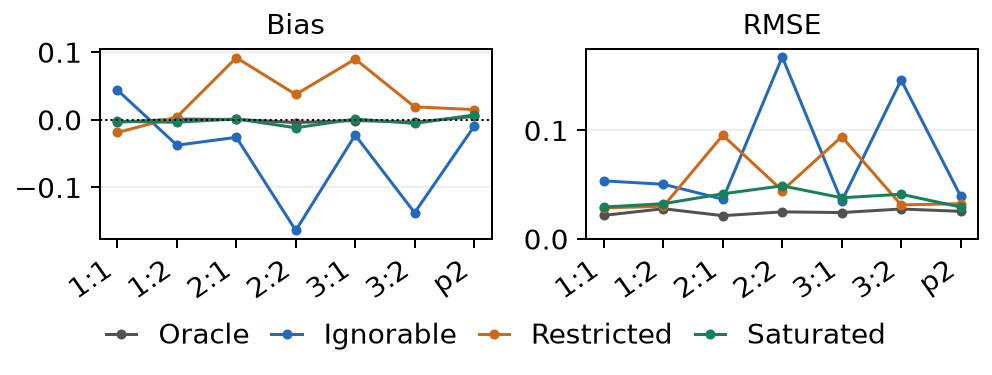

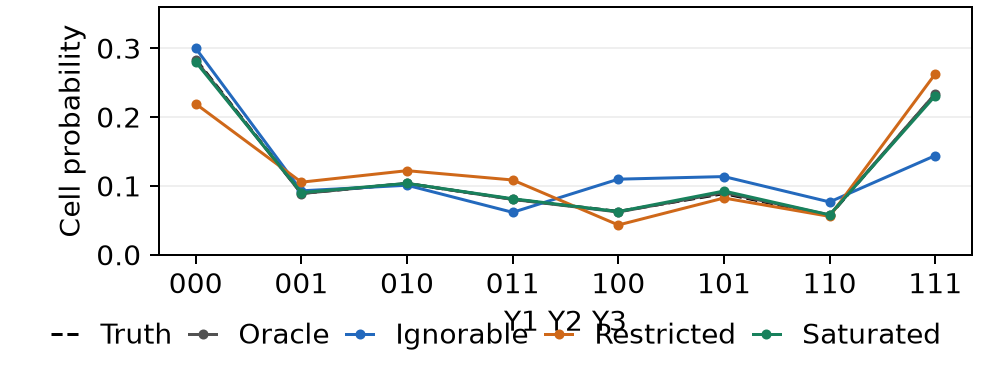

In [2]:
display(diagnostics.groupby(['mechanism','method'])[['boundary','valid_se','stationary','item_rate','complete_rate']].mean())
display(summary[(summary.mechanism=='MNAR') & summary.parameter.isin(['M2_class2','M3_class2','p_class2','mean_Y2','mean_Y3'])].round(4))
for name in ['slide_outcome_point','slide_outcome_inference','slide_latent_point','slide_joint']:
    display(Image(filename=str(report.OUT/(name+'.png'))))

## 限界
候補法のMNARのCIは81/100でのみ計算可能で、coverage_validを全反復のcoverageと呼べない。
MCAR/MARではFIMLに比べ追加推定の分散コストがある。正指定飽和logisticに対する優位性を示す実験ではない。
応答独立性・測定exclusion・既知クラス数の誤指定は許容しない。
このシミュレーションは旧bridge推定量の定理やglobal complete case不存在の場合を検証していない。